### Selecting pointing IDs for GELSA spectra simulation

> Execute this code before running simulations with **"simulation_full_dataset_*.py"** scripts.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from astropy.io import fits
from astropy.table import Table, unique

In [2]:
filename = "/scratch/astro/nicolo.fiaba/EDFN_deep.fits"
hdu_list = fits.open(filename, memmap=True)
data = Table(hdu_list[1].data)

pointing_filename = "/scratch/astro/nicolo.fiaba/pointing_list.txt"
pointings = Table.read(pointing_filename, format='ascii')
len(pointings)

324

In [3]:
size_per_config = 6

#### We want to avoid picking different pointing numbers referring to the same pointing ID

In [4]:
pointings = unique(pointings, keys='Data.ObservationSequence.PointingId')

In [10]:
pointings[pointings["Data.ObservationSequence.PointingId"] == 30399]

Data.ObservationSequence.ObservationId,Data.ObservationSequence.PatchId,Data.ObservationSequence.PointingId,Data.ObservationSequence.DitherObservation,Data.AdjustedPointing.RA,Data.AdjustedPointing.Dec,Data.AdjustedPointing.PositionAngle,Data.Grism,Data.GrismWheelTilt
int64,int64,int64,int64,float64,float64,float64,str6,float64
6879,151,30399,1,267.743702169829,66.7216852582687,82.2564676165333,RGS180,4.0


In [8]:
print(pointings[pointings["Data.ObservationSequence.PointingId"] == 30399]["Data.AdjustedPointing.RA"])
print(pointings[pointings["Data.ObservationSequence.PointingId"] == 30399]["Data.AdjustedPointing.Dec"])

Data.AdjustedPointing.RA
------------------------
        267.743702169829
Data.AdjustedPointing.Dec
-------------------------
         66.7216852582687


#### We also want to avoid selecting pointings close to the border of EDFN catalog, otherwise no sources will be simulated in certain detectors

In [5]:
mask_dec = (pointings['Data.AdjustedPointing.Dec'] < 68) & (pointings['Data.AdjustedPointing.Dec'] > 64)

In [6]:
np.random.seed(10)

m1 = (pointings["Data.GrismWheelTilt"] == 0.0) & (pointings["Data.Grism"] == 'RGS000') & mask_dec
m2 = (pointings["Data.GrismWheelTilt"] == -4.0) & (pointings["Data.Grism"] == 'RGS000') & mask_dec
m3 = (pointings["Data.GrismWheelTilt"] == 0.0) & (pointings["Data.Grism"] == 'RGS180') & mask_dec
m4 = (pointings["Data.GrismWheelTilt"] == 4.0) & (pointings["Data.Grism"] == 'RGS180') & mask_dec

idx1 = np.where(m1)[0]
idx2 = np.where(m2)[0]
idx3 = np.where(m3)[0]
idx4 = np.where(m4)[0]

rand_indices = []

rand_indices.extend(np.random.choice(idx1, size=size_per_config, replace=False))
rand_indices.extend(np.random.choice(idx2, size=size_per_config, replace=False))
rand_indices.extend(np.random.choice(idx3, size=size_per_config, replace=False))
rand_indices.extend(np.random.choice(idx4, size=size_per_config, replace=False))

print(rand_indices)

[104, 28, 20, 8, 12, 108, 162, 14, 22, 138, 106, 82, 31, 123, 15, 19, 99, 159, 25, 137, 29, 157, 21, 49]


In [15]:
# Check tilts of selected pointings
tilts = [int(pointings["Data.GrismWheelTilt"][ri]) for ri in rand_indices]
grisms = [pointings["Data.Grism"][ri] for ri in rand_indices]
[(gr, tlt) for gr, tlt in zip(grisms, tilts)]

[('RGS000', 0),
 ('RGS000', 0),
 ('RGS000', 0),
 ('RGS000', 0),
 ('RGS000', 0),
 ('RGS000', 0),
 ('RGS000', -4),
 ('RGS000', -4),
 ('RGS000', -4),
 ('RGS000', -4),
 ('RGS000', -4),
 ('RGS000', -4),
 ('RGS180', 0),
 ('RGS180', 0),
 ('RGS180', 0),
 ('RGS180', 0),
 ('RGS180', 0),
 ('RGS180', 0),
 ('RGS180', 4),
 ('RGS180', 4),
 ('RGS180', 4),
 ('RGS180', 4),
 ('RGS180', 4),
 ('RGS180', 4)]

In [21]:
# Check the ID of the randomly extracted pointings
pt_ids = [int(pointings["Data.ObservationSequence.PointingId"][ri]) for ri in rand_indices]
print(*pt_ids,sep=' ')

30454 30378 30370 30358 30362 30458 30512 30364 30372 30488 30456 30432 30381 30473 30365 30369 30449 30509 30375 30487 30379 30507 30371 30399


In [20]:
# Check that they are all different
pt_ids = np.array(pt_ids)
print(len(pt_ids), len(np.unique(pt_ids)))

24 24


#### Now we can check where those selected poitings fall with respect to the area covered by *EDFN_deep* catalog

In [18]:
pt_ns = [np.where(pointings["Data.ObservationSequence.PointingId"] == pt_id)[0][0] for pt_id in pt_ids]
print(pt_ns)

[104, 28, 20, 8, 12, 108, 162, 14, 22, 138, 106, 82, 31, 123, 15, 19, 99, 159, 25, 137, 29, 157, 21, 49]


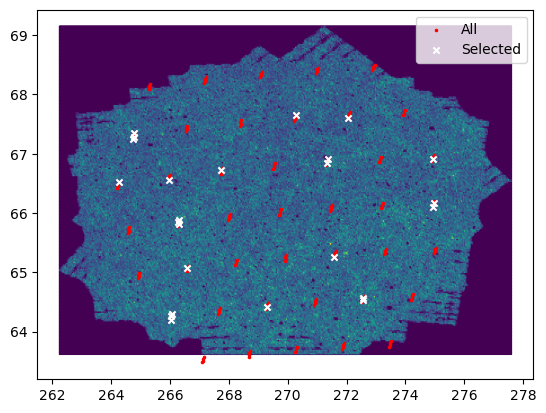

In [19]:
plt.hexbin(data['RIGHT_ASCENSION'], data['DECLINATION'], gridsize=400)
plt.scatter(pointings['Data.AdjustedPointing.RA'], pointings['Data.AdjustedPointing.Dec'], c='red', marker='.',
            s=10, label='All')
plt.scatter(pointings[pt_ns]['Data.AdjustedPointing.RA'], pointings[pt_ns]['Data.AdjustedPointing.Dec'], c='white', marker='x', 
            s=20, label='Selected')
plt.legend()